In [1]:
import pandas as pd

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
DATA_PATH = "/content/drive/MyDrive/datasets/MLDAS.csv"

df = pd.read_csv(DATA_PATH, nrows=100000)

print("Dataset loaded successfully")
print("Shape (rows, columns):", df.shape)

df.head()

Dataset loaded successfully
Shape (rows, columns): (100000, 31)


,hour_sin,hour_cos,week_day,latitude,longitude,wind,precipitation,temperature,lanes,maxspeed,...,month_7,month_8,month_9,month_10,month_11,month_12,highway,oneway,id,traffic_intensity
0,0.010103,1.416502,-0.500144,0.448076,-0.873747,-0.939681,-0.228171,-0.678113,-0.69598,0.278713,...,0.0,0.0,0.0,0.0,0.0,0.0,7.0,1.0,3397.0,209.0
1,0.102705,1.413477,-0.500144,0.448076,-0.873747,-0.939681,-0.228171,-0.678113,-0.69598,0.278713,...,0.0,0.0,0.0,0.0,0.0,0.0,7.0,1.0,3397.0,201.0
2,0.194910,1.404416,-0.500144,0.448076,-0.873747,-0.939681,-0.228171,-0.678113,-0.69598,0.278713,...,0.0,0.0,0.0,0.0,0.0,0.0,7.0,1.0,3397.0,212.0
3,0.286324,1.389358,-0.500144,0.448076,-0.873747,-0.939681,-0.228171,-0.678113,-0.69598,0.278713,...,0.0,0.0,0.0,0.0,0.0,0.0,7.0,1.0,3397.0,148.0
4,0.376556,1.368367,-0.500144,0.448076,-0.873747,-0.939681,-0.228171,-0.678113,-0.69598,0.278713,...,0.0,0.0,0.0,0.0,0.0,0.0,7.0,1.0,3397.0,144.0


In [4]:
keep_columns = [
    "hour_sin", "hour_cos", "week_day",
    "latitude", "longitude",
    "wind", "precipitation", "temperature",
    "lanes", "maxspeed", "length",
    "highway", "oneway",
    "traffic_intensity"
]

df = df[keep_columns]

df = df.iloc[:80000]

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (80000, 14)


,hour_sin,hour_cos,week_day,latitude,longitude,wind,precipitation,temperature,lanes,maxspeed,length,highway,oneway,traffic_intensity
0,0.010103,1.416502,-0.500144,0.448076,-0.873747,-0.939681,-0.228171,-0.678113,-0.69598,0.278713,-0.382244,7.0,1.0,209.0
1,0.102705,1.413477,-0.500144,0.448076,-0.873747,-0.939681,-0.228171,-0.678113,-0.69598,0.278713,-0.382244,7.0,1.0,201.0
2,0.194910,1.404416,-0.500144,0.448076,-0.873747,-0.939681,-0.228171,-0.678113,-0.69598,0.278713,-0.382244,7.0,1.0,212.0
3,0.286324,1.389358,-0.500144,0.448076,-0.873747,-0.939681,-0.228171,-0.678113,-0.69598,0.278713,-0.382244,7.0,1.0,148.0
4,0.376556,1.368367,-0.500144,0.448076,-0.873747,-0.939681,-0.228171,-0.678113,-0.69598,0.278713,-0.382244,7.0,1.0,144.0


In [5]:
df = pd.get_dummies(df, columns=["highway", "oneway"], drop_first=True)

df.head()

,hour_sin,hour_cos,week_day,latitude,longitude,wind,precipitation,temperature,lanes,maxspeed,length,traffic_intensity,highway_7.0
0,0.010103,1.416502,-0.500144,0.448076,-0.873747,-0.939681,-0.228171,-0.678113,-0.69598,0.278713,-0.382244,209.0,True
1,0.102705,1.413477,-0.500144,0.448076,-0.873747,-0.939681,-0.228171,-0.678113,-0.69598,0.278713,-0.382244,201.0,True
2,0.194910,1.404416,-0.500144,0.448076,-0.873747,-0.939681,-0.228171,-0.678113,-0.69598,0.278713,-0.382244,212.0,True
3,0.286324,1.389358,-0.500144,0.448076,-0.873747,-0.939681,-0.228171,-0.678113,-0.69598,0.278713,-0.382244,148.0,True
4,0.376556,1.368367,-0.500144,0.448076,-0.873747,-0.939681,-0.228171,-0.678113,-0.69598,0.278713,-0.382244,144.0,True


In [6]:
from sklearn.preprocessing import StandardScaler

target = "traffic_intensity"
features = [col for col in df.columns if col != target]

scaler = StandardScaler()
df[features] = scaler.fit_transform(df[features])

df.head()

,hour_sin,hour_cos,week_day,latitude,longitude,wind,precipitation,temperature,lanes,maxspeed,length,traffic_intensity,highway_7.0
0,0.001995,1.413409,-0.498375,0.559852,0.559852,-0.950359,-0.224751,-0.697744,0.0,0.0,-0.559852,209.0,0.559852
1,0.094458,1.410380,-0.498375,0.559852,0.559852,-0.950359,-0.224751,-0.697744,0.0,0.0,-0.559852,201.0,0.559852
2,0.186524,1.401306,-0.498375,0.559852,0.559852,-0.950359,-0.224751,-0.697744,0.0,0.0,-0.559852,212.0,0.559852
3,0.277801,1.386226,-0.498375,0.559852,0.559852,-0.950359,-0.224751,-0.697744,0.0,0.0,-0.559852,148.0,0.559852
4,0.367896,1.365205,-0.498375,0.559852,0.559852,-0.950359,-0.224751,-0.697744,0.0,0.0,-0.559852,144.0,0.559852


In [8]:
INPUT_SIZE = len(features)

print(f"INPUT_SIZE = {INPUT_SIZE}")
print("\nColumn order:")
for i, col in enumerate(features):
    print(f"  index {i:2d} = {col}")


INPUT_SIZE = 12

Column order:
  index  0 = hour_sin
  index  1 = hour_cos
  index  2 = week_day
  index  3 = latitude
  index  4 = longitude
  index  5 = wind
  index  6 = precipitation
  index  7 = temperature
  index  8 = lanes
  index  9 = maxspeed
  index 10 = length
  index 11 = highway_7.0


In [9]:
print("\nTraffic intensity distribution:")
print(df[target].describe())

p75 = df[target].quantile(0.75)
p90 = df[target].quantile(0.90)

print(f"\n75th percentile (p75) = {p75:.2f}")
print(f"90th percentile (p90) = {p90:.2f}")
print(f"\nHEAVY_TRAFFIC_THRESHOLD = {p75:.0f}")


Traffic intensity distribution:
count    80000.000000
mean       379.590937
std        221.663060
min          0.000000
25%        187.000000
50%        389.000000
75%        520.000000
max       1453.000000
Name: traffic_intensity, dtype: float64

75th percentile (p75) = 520.00
90th percentile (p90) = 644.00

HEAVY_TRAFFIC_THRESHOLD = 520


In [10]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np

class TrafficDataset(Dataset):
    def __init__(self, df, window=12):
        self.X = df.drop(columns=[target]).astype(np.float32).values
        self.y = df[target].astype(np.float32).values
        self.window = window

    def __len__(self):
        return len(self.X) - self.window

    def __getitem__(self, idx):
        x = self.X[idx : idx + self.window]
        y = self.y[idx + self.window]
        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32)
        )

In [11]:

dataset = TrafficDataset(df, window=12)

total     = len(dataset)
train_n   = int(0.70 * total)
val_n     = int(0.15 * total)
test_n    = total - train_n - val_n

train_ds, val_ds, test_ds = torch.utils.data.random_split(
    dataset,
    [train_n, val_n, test_n]
)

print(f"\nDataset split:")
print(f"  Training   samples: {train_n}")
print(f"  Validation samples: {val_n}")
print(f"  Test       samples: {test_n}")

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {device}")



Dataset split:
  Training   samples: 55991
  Validation samples: 11998
  Test       samples: 11999

Using device: cpu


In [12]:

class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size=64):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, batch_first=True)
        self.fc  = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])


class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=64):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc   = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])


class CNN1DModel(nn.Module):
    def __init__(self, input_size, hidden_size=64):
        super().__init__()
        self.conv1 = nn.Conv1d(input_size, hidden_size, kernel_size=3, padding=1)
        self.relu  = nn.ReLU()
        self.fc    = nn.Linear(hidden_size, 1)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.conv1(x)
        x = self.relu(x)
        x = x.mean(dim=2)
        return self.fc(x)

In [13]:

def train_model(model, train_loader, val_loader, epochs=200, lr=0.001, verbose=False):
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    val_losses   = []

    for epoch in range(epochs):

        model.train()
        running = 0
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            preds = model(X).squeeze()
            loss  = criterion(preds, y)
            loss.backward()
            optimizer.step()
            running += loss.item()

        train_loss = running / len(train_loader)
        train_losses.append(train_loss)

        model.eval()
        val_running = 0
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)
                preds = model(X).squeeze()
                loss  = criterion(preds, y)
                val_running += loss.item()

        val_loss = val_running / len(val_loader)
        val_losses.append(val_loss)

        if verbose and (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

    return model, train_losses, val_losses

In [14]:

print("\nTraining GRU...")
gru_model, gru_train, gru_val = train_model(
    GRUModel(INPUT_SIZE), train_loader, val_loader, epochs=200, verbose=True
)

print("\nTraining LSTM...")
lstm_model, lstm_train, lstm_val = train_model(
    LSTMModel(INPUT_SIZE), train_loader, val_loader, epochs=200, verbose=True
)

print("\nTraining CNN...")
cnn_model, cnn_train, cnn_val = train_model(
    CNN1DModel(INPUT_SIZE), train_loader, val_loader, epochs=200, verbose=True
)


Training GRU...
Epoch 10/200 | Train: 22514.5603 | Val: 20526.6738
Epoch 20/200 | Train: 9620.9198 | Val: 9395.6100
Epoch 30/200 | Train: 9040.3456 | Val: 8834.7533
Epoch 40/200 | Train: 8839.9382 | Val: 8701.1121
Epoch 50/200 | Train: 8513.1771 | Val: 8421.2197
Epoch 60/200 | Train: 8236.7124 | Val: 8245.8220
Epoch 70/200 | Train: 7941.6237 | Val: 8131.2099
Epoch 80/200 | Train: 7488.4870 | Val: 7951.4658
Epoch 90/200 | Train: 7193.1814 | Val: 7613.8540
Epoch 100/200 | Train: 6920.4076 | Val: 7563.1295
Epoch 110/200 | Train: 6767.9607 | Val: 7476.5193
Epoch 120/200 | Train: 6672.0963 | Val: 7399.4801
Epoch 130/200 | Train: 6583.3781 | Val: 7402.3104
Epoch 140/200 | Train: 6498.2008 | Val: 7316.3476
Epoch 150/200 | Train: 6435.9430 | Val: 7292.9960
Epoch 160/200 | Train: 6305.9297 | Val: 7314.4098
Epoch 170/200 | Train: 6286.1979 | Val: 7523.3068
Epoch 180/200 | Train: 6157.7294 | Val: 7191.6114
Epoch 190/200 | Train: 6172.9214 | Val: 7325.4840
Epoch 200/200 | Train: 6056.0294 | Val: 

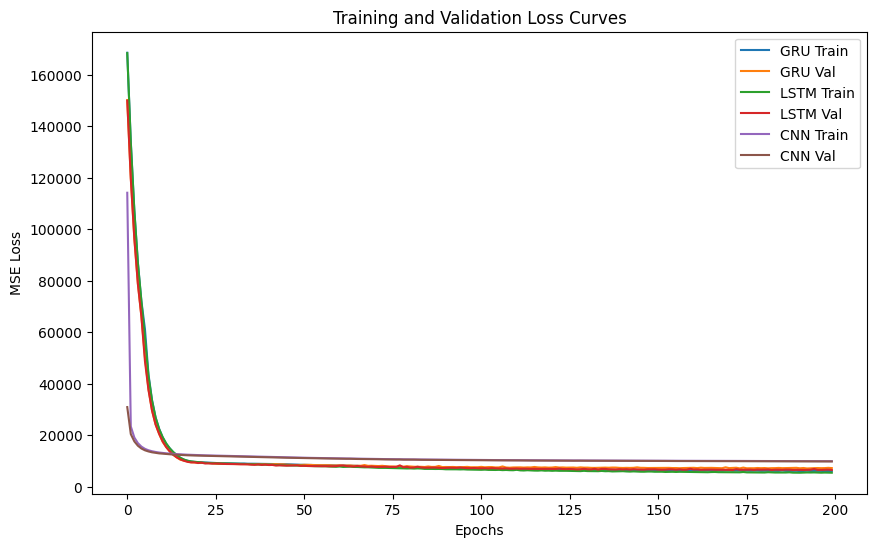

In [15]:

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(gru_train,  label="GRU Train")
plt.plot(gru_val,    label="GRU Val")
plt.plot(lstm_train, label="LSTM Train")
plt.plot(lstm_val,   label="LSTM Val")
plt.plot(cnn_train,  label="CNN Train")
plt.plot(cnn_val,    label="CNN Val")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Training and Validation Loss Curves")
plt.legend()
plt.show()

In [16]:

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(model, loader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            preds = model(X).squeeze()
            y_true.extend(y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    return mae, rmse, r2


gru_val_mae,  gru_val_rmse,  gru_val_r2  = evaluate_model(gru_model,  val_loader)
lstm_val_mae, lstm_val_rmse, lstm_val_r2  = evaluate_model(lstm_model, val_loader)
cnn_val_mae,  cnn_val_rmse,  cnn_val_r2   = evaluate_model(cnn_model,  val_loader)

print("\n--- Model Comparison (Validation Set) ---")
print(f"{'Model':10} {'Val R2':>10} {'Val MAE':>10} {'Val RMSE':>12}")
print(f"{'GRU':10} {gru_val_r2:10.3f} {gru_val_mae:10.2f} {gru_val_rmse:12.2f}")
print(f"{'LSTM':10} {lstm_val_r2:10.3f} {lstm_val_mae:10.2f} {lstm_val_rmse:12.2f}")
print(f"{'CNN':10} {cnn_val_r2:10.3f} {cnn_val_mae:10.2f} {cnn_val_rmse:12.2f}")

mae_list    = [gru_val_mae, lstm_val_mae, cnn_val_mae]
r2_list     = [gru_val_r2,  lstm_val_r2,  cnn_val_r2]
models_list = ["GRU", "LSTM", "CNN"]

best_idx  = mae_list.index(min(mae_list))
best_name = models_list[best_idx]
print(f"\nBest model selected: {best_name}")



--- Model Comparison (Validation Set) ---
Model          Val R2    Val MAE     Val RMSE
GRU             0.852      59.74        85.02
LSTM            0.867      56.96        80.49
CNN             0.800      69.95        98.94

Best model selected: LSTM


In [17]:

print("\nStarting hyperparameter tuning for LSTM...")


class TunableLSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super().__init__()
        if num_layers == 1:
            dropout = 0.0
        self.lstm = nn.LSTM(
            input_size, hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])


def train_once(model, train_loader, val_loader, lr, epochs=15):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    for _ in range(epochs):
        model.train()
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            preds = model(X).squeeze()
            loss  = criterion(preds, y)
            loss.backward()
            optimizer.step()

    model.eval()
    total = 0
    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device)
            preds = model(X).squeeze()
            total += criterion(preds, y).item()
    return total / len(val_loader)


hidden_sizes      = [64, 128]
num_layers_options = [1, 2]
dropouts          = [0.0, 0.3]
learning_rates    = [0.001, 0.0005]

best_loss   = float("inf")
best_config = None

for hidden in hidden_sizes:
    for layers in num_layers_options:
        for dropout in dropouts:
            for lr in learning_rates:
                print(f"Testing: hidden={hidden}, layers={layers}, dropout={dropout}, lr={lr}")
                model = TunableLSTMModel(INPUT_SIZE, hidden, layers, dropout).to(device)
                loss  = train_once(model, train_loader, val_loader, lr)
                print(f"  Validation loss: {loss:.4f}")
                if loss < best_loss:
                    best_loss   = loss
                    best_config = (hidden, layers, dropout, lr)

print(f"\nBest config: hidden={best_config[0]}, layers={best_config[1]}, "
      f"dropout={best_config[2]}, lr={best_config[3]}")
print(f"Best validation loss: {best_loss:.4f}")


Starting hyperparameter tuning for LSTM...
Testing: hidden=64, layers=1, dropout=0.0, lr=0.001
  Validation loss: 11352.3320
Testing: hidden=64, layers=1, dropout=0.0, lr=0.0005
  Validation loss: 28572.2061
Testing: hidden=64, layers=1, dropout=0.3, lr=0.001
  Validation loss: 11419.5671
Testing: hidden=64, layers=1, dropout=0.3, lr=0.0005
  Validation loss: 28589.4601
Testing: hidden=64, layers=2, dropout=0.0, lr=0.001
  Validation loss: 11379.0381
Testing: hidden=64, layers=2, dropout=0.0, lr=0.0005
  Validation loss: 29649.4533
Testing: hidden=64, layers=2, dropout=0.3, lr=0.001
  Validation loss: 11213.0951
Testing: hidden=64, layers=2, dropout=0.3, lr=0.0005
  Validation loss: 28897.7713
Testing: hidden=128, layers=1, dropout=0.0, lr=0.001
  Validation loss: 9875.8781
Testing: hidden=128, layers=1, dropout=0.0, lr=0.0005
  Validation loss: 11629.8483
Testing: hidden=128, layers=1, dropout=0.3, lr=0.001
  Validation loss: 9049.2441
Testing: hidden=128, layers=1, dropout=0.3, lr=0


Retraining LSTM with best hyperparameters...
Epoch 20/200 | Train: 9071.50 | Val: 8824.19
Epoch 40/200 | Train: 8199.97 | Val: 8247.58
Epoch 60/200 | Train: 6796.08 | Val: 7265.80
Epoch 80/200 | Train: 6180.82 | Val: 6841.05
Epoch 100/200 | Train: 5780.71 | Val: 6689.34
Epoch 120/200 | Train: 5495.33 | Val: 6646.30
Epoch 140/200 | Train: 5278.25 | Val: 6620.28
Epoch 160/200 | Train: 5181.83 | Val: 6750.47
Epoch 180/200 | Train: 4956.05 | Val: 6642.99
Epoch 200/200 | Train: 4913.01 | Val: 6727.79


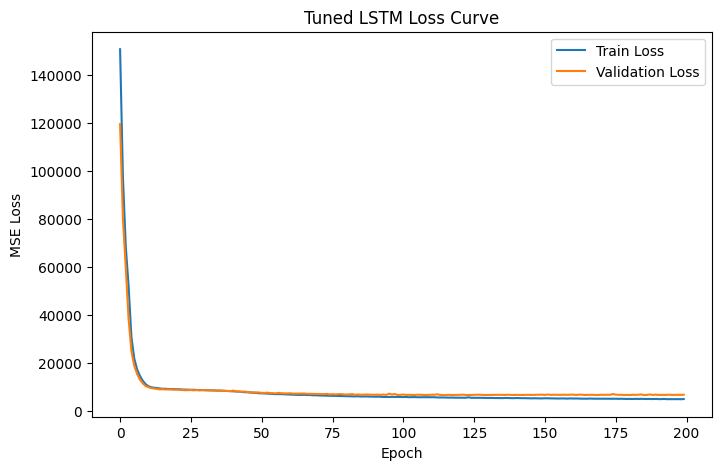

Best epoch: 116
Lowest validation loss: 6554.7550


In [18]:

print("\nRetraining LSTM with best hyperparameters...")

hidden, layers, dropout, lr = best_config

final_lstm = TunableLSTMModel(INPUT_SIZE, hidden, layers, dropout).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(final_lstm.parameters(), lr=lr)

final_train_losses = []
final_val_losses   = []

for epoch in range(200):
    final_lstm.train()
    train_loss = 0
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        preds = final_lstm(X).squeeze()
        loss  = criterion(preds, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    final_lstm.eval()
    val_loss = 0
    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device)
            preds = final_lstm(X).squeeze()
            val_loss += criterion(preds, y).item()
    val_loss /= len(val_loader)

    final_train_losses.append(train_loss)
    final_val_losses.append(val_loss)

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/200 | Train: {train_loss:.2f} | Val: {val_loss:.2f}")

plt.figure(figsize=(8, 5))
plt.plot(final_train_losses, label="Train Loss")
plt.plot(final_val_losses,   label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Tuned LSTM Loss Curve")
plt.legend()
plt.show()

best_epoch = np.argmin(final_val_losses) + 1
print(f"Best epoch: {best_epoch}")
print(f"Lowest validation loss: {min(final_val_losses):.4f}")


In [19]:

print("\n--- Final Evaluation on Unseen Test Set ---")

test_mae, test_rmse, test_r2 = evaluate_model(final_lstm, test_loader)
print(f"Tuned LSTM | Test MAE: {test_mae:.2f} | Test RMSE: {test_rmse:.2f} | Test R2: {test_r2:.4f}")

gru_test_mae,  gru_test_rmse,  gru_test_r2  = evaluate_model(gru_model,  test_loader)
lstm_test_mae, lstm_test_rmse, lstm_test_r2  = evaluate_model(lstm_model, test_loader)
cnn_test_mae,  cnn_test_rmse,  cnn_test_r2   = evaluate_model(cnn_model,  test_loader)

print(f"\n--- Full Model Comparison on Test Set ---")
print(f"{'Model':15} {'Test R2':>10} {'Test MAE':>10} {'Test RMSE':>12}")
print(f"{'GRU':15} {gru_test_r2:10.3f} {gru_test_mae:10.2f} {gru_test_rmse:12.2f}")
print(f"{'LSTM':15} {lstm_test_r2:10.3f} {lstm_test_mae:10.2f} {lstm_test_rmse:12.2f}")
print(f"{'CNN':15} {cnn_test_r2:10.3f} {cnn_test_mae:10.2f} {cnn_test_rmse:12.2f}")
print(f"{'Tuned LSTM':15} {test_r2:10.3f} {test_mae:10.2f} {test_rmse:12.2f}")



--- Final Evaluation on Unseen Test Set ---
Tuned LSTM | Test MAE: 57.87 | Test RMSE: 82.38 | Test R2: 0.8618

--- Full Model Comparison on Test Set ---
Model              Test R2   Test MAE    Test RMSE
GRU                  0.850      60.17        85.69
LSTM                 0.865      57.66        81.49
CNN                  0.794      70.44       100.59
Tuned LSTM           0.862      57.87        82.38



Training uncertainty model...
Epoch 10/200 | Train: 27715.56 | Val: 23168.83
Epoch 20/200 | Train: 11450.69 | Val: 9601.71
Epoch 30/200 | Train: 10632.14 | Val: 9184.74
Epoch 40/200 | Train: 10415.21 | Val: 8710.46
Epoch 50/200 | Train: 10163.42 | Val: 8617.39
Epoch 60/200 | Train: 9997.92 | Val: 8558.05
Epoch 70/200 | Train: 9812.45 | Val: 8300.40
Epoch 80/200 | Train: 9591.58 | Val: 8251.39
Epoch 90/200 | Train: 9365.50 | Val: 8119.94
Epoch 100/200 | Train: 9113.40 | Val: 7949.38
Epoch 110/200 | Train: 8920.03 | Val: 7923.85
Epoch 120/200 | Train: 8684.20 | Val: 7629.82
Epoch 130/200 | Train: 8530.84 | Val: 7636.17
Epoch 140/200 | Train: 8242.12 | Val: 7519.29
Epoch 150/200 | Train: 8125.28 | Val: 7682.15
Epoch 160/200 | Train: 8023.69 | Val: 7433.58
Epoch 170/200 | Train: 7886.14 | Val: 7349.65
Epoch 180/200 | Train: 7742.23 | Val: 7337.41
Epoch 190/200 | Train: 7721.22 | Val: 7301.43
Epoch 200/200 | Train: 7676.51 | Val: 7222.20


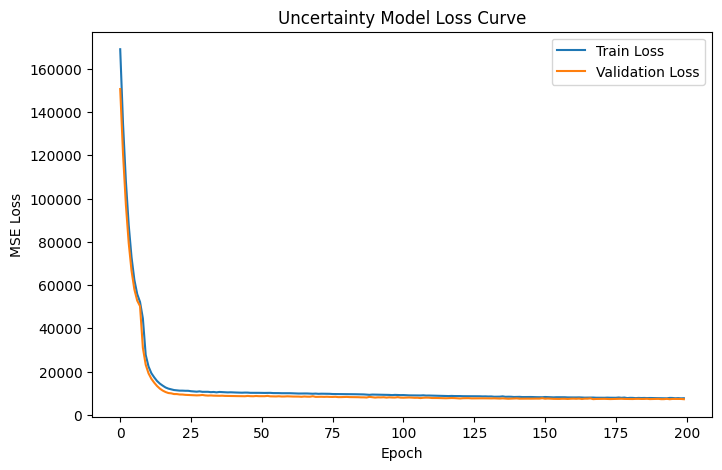

Best uncertainty epoch: 195
Lowest validation loss: 7210.5927


In [20]:

print("\nTraining uncertainty model...")


class GRUUncertaintyModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, dropout=0.3):
        super().__init__()
        self.gru     = nn.GRU(input_size, hidden_size, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]
        out = self.dropout(out)
        return self.fc(out)


uncert_model = GRUUncertaintyModel(INPUT_SIZE).to(device)
criterion    = nn.MSELoss()
optimizer    = torch.optim.Adam(uncert_model.parameters(), lr=0.001)

uncert_train_losses = []
uncert_val_losses   = []
best_uncert_loss    = float("inf")
best_uncert_weights = None

for epoch in range(200):
    uncert_model.train()
    train_loss = 0
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        preds = uncert_model(X).squeeze()
        loss  = criterion(preds, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    uncert_model.eval()
    val_loss = 0
    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device)
            preds = uncert_model(X).squeeze()
            val_loss += criterion(preds, y).item()
    val_loss /= len(val_loader)

    uncert_train_losses.append(train_loss)
    uncert_val_losses.append(val_loss)

    if val_loss < best_uncert_loss:
        best_uncert_loss    = val_loss
        best_uncert_weights = uncert_model.state_dict()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/200 | Train: {train_loss:.2f} | Val: {val_loss:.2f}")

uncert_model.load_state_dict(best_uncert_weights)

plt.figure(figsize=(8, 5))
plt.plot(uncert_train_losses, label="Train Loss")
plt.plot(uncert_val_losses,   label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Uncertainty Model Loss Curve")
plt.legend()
plt.show()

print(f"Best uncertainty epoch: {np.argmin(uncert_val_losses) + 1}")
print(f"Lowest validation loss: {min(uncert_val_losses):.4f}")


In [21]:
import joblib

final_lstm.eval()
with torch.no_grad():
    X_sample, y_sample = next(iter(test_loader))
    X_sample = X_sample.to(device)
    preds = final_lstm(X_sample).squeeze().cpu().numpy()

print("\nSanity check — LSTM predictions vs actual:")
for i in range(5):
    print(f"  Predicted: {preds[i]:.1f}  |  Actual: {y_sample[i].numpy():.1f}")


def mc_dropout_predict(model, X, samples=20):
    model.train()
    preds = []
    with torch.no_grad():
        for _ in range(samples):
            preds.append(model(X).squeeze().cpu().numpy())
    preds = np.array(preds)
    return preds.mean(axis=0), preds.std(axis=0)


mean_pred, uncert = mc_dropout_predict(uncert_model, X_sample)
print("\nSanity check — MC Dropout uncertainty:")
for i in range(5):
    print(f"  Mean: {mean_pred[i]:.1f}  |  Uncertainty: ±{uncert[i]:.1f}")



Sanity check — LSTM predictions vs actual:
  Predicted: 280.3  |  Actual: 216.0
  Predicted: 970.4  |  Actual: 1048.0
  Predicted: 207.3  |  Actual: 140.0
  Predicted: 283.4  |  Actual: 269.0
  Predicted: 336.6  |  Actual: 240.0

Sanity check — MC Dropout uncertainty:
  Mean: 278.7  |  Uncertainty: ±22.5
  Mean: 958.7  |  Uncertainty: ±89.4
  Mean: 185.0  |  Uncertainty: ±17.9
  Mean: 268.1  |  Uncertainty: ±21.9
  Mean: 268.9  |  Uncertainty: ±24.0


In [22]:

feature_array = df.drop(columns=[target]).astype(np.float32).values
default_sequence = feature_array[-12:]
np.save("default_sequence.npy", default_sequence)
print(f"\nDefault sequence saved — shape: {default_sequence.shape}")


Default sequence saved — shape: (12, 12)


In [23]:

torch.save(final_lstm.state_dict(),   "best_traffic_model.pt")
torch.save(uncert_model.state_dict(), "uncert_gru_model.pt")
joblib.dump(scaler,                   "scaler.pkl")

print("\nAll models saved.")
print(f"INPUT_SIZE for UI = {INPUT_SIZE}")
print(f"HEAVY_TRAFFIC_THRESHOLD for UI = {p75:.0f}")


All models saved.
INPUT_SIZE for UI = 12
HEAVY_TRAFFIC_THRESHOLD for UI = 520


In [24]:

from google.colab import files

files.download("best_traffic_model.pt")
files.download("uncert_gru_model.pt")
files.download("scaler.pkl")
files.download("default_sequence.npy")



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>